In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Set the style for seaborn
sns.set(style="darkgrid")

pastel_red = 'rgba(255, 99, 132, 0.6)'
pastel_green = 'rgba(144, 238, 144, 0.6)'
Pastel_yellow ='rgba(255, 223, 102, 0.6)'
Pastel_blue = 'rgba(173, 216, 230, 0.6)'	
Pastel_purple = 'rgba(218, 112, 214, 0.6)'	
Pastel_orange = 'rgba(255, 179, 102, 0.6)'	
Pastel_gray = 'rgba(200, 200, 200, 0.6)'

sns.set_style('darkgrid')
plt.style.use('dark_background')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [6]:
target_cols = ['RainTomorrow']

In [12]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
test_inputs = pd.read_parquet('test_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')[target_cols]
val_targets = pd.read_parquet('val_targets.parquet')[target_cols]
test_targets = pd.read_parquet('test_targets.parquet')[target_cols]

In [13]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)
print('test_inputs:', test_inputs.shape)
print('test_targets:', test_targets.shape)

train_inputs: (97988, 123)
train_targets: (97988, 1)
val_inputs: (17089, 123)
val_targets: (17089, 1)
test_inputs: (25710, 123)
test_targets: (25710, 1)


In [17]:
numeric_cols = train_inputs.select_dtypes(include='number').columns.to_list()
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'Location_Adelaide',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',

## Training a Logistic Regression Model

Logistic regression is a commonly used technique for solving binary classification problems. In a logistic regression model: 

- we take linear combination (or weighted sum of the input features) 
- we apply the sigmoid function to the result to obtain a number between 0 and 1
- this number represents the probability of the input being classified as "Yes"
- instead of RMSE, the cross entropy loss function is used to evaluate the results


Here's a visual summary of how a logistic regression model is structured ([source](http://datahacker.rs/005-pytorch-logistic-regression-in-pytorch/)):


<img src="https://i.imgur.com/YMaMo5D.png" width="480">

The sigmoid function applied to the linear combination of inputs has the following formula:

<img src="https://i.imgur.com/sAVwvZP.png" width="400">

To train a logistic regression model, we can use the `LogisticRegression` class from Scikit-learn.

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model  = LogisticRegression(solver='liblinear')

In [20]:
model.fit(train_inputs[numeric_cols], train_targets)

C:\Users\Sanjai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

`model.fit` uses the following workflow for training the model :

1. We initialize a model with random parameters (weights & biases).
2. We pass some inputs into the model to obtain predictions.
3. We compare the model's predictions with the actual targets using the loss function.  
4. We use an optimization technique (like least squares, gradient descent etc.) to reduce the loss by adjusting the weights & biases of the model
5. We repeat steps 1 to 4 till the predictions from the model are good enough.


<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

Logistic regression can also be applied to multi-class classification problems, with a few modifications.

In [28]:
feature_names = numeric_cols
coefficients  = np.array(model.coef_).flatten()

coef_df = pd.DataFrame({'Feature': feature_names,
                        'Coefficient': coefficients})

coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
coef_df

,Feature,Coefficient
11,Pressure3pm,-9.176802
5,WindGustSpeed,6.764395
9,Humidity3pm,5.995317
10,Pressure9am,5.463852
2,Rainfall,3.162777
...,...,...
97,WindDir9am_WSW,-0.016127
24,Location_Cairns,-0.013981
37,Location_Moree,0.013383
41,Location_Nhil,0.008519


In [22]:
model.intercept_

array([-2.44955488])

<Axes: xlabel='Coefficient', ylabel='Feature'>

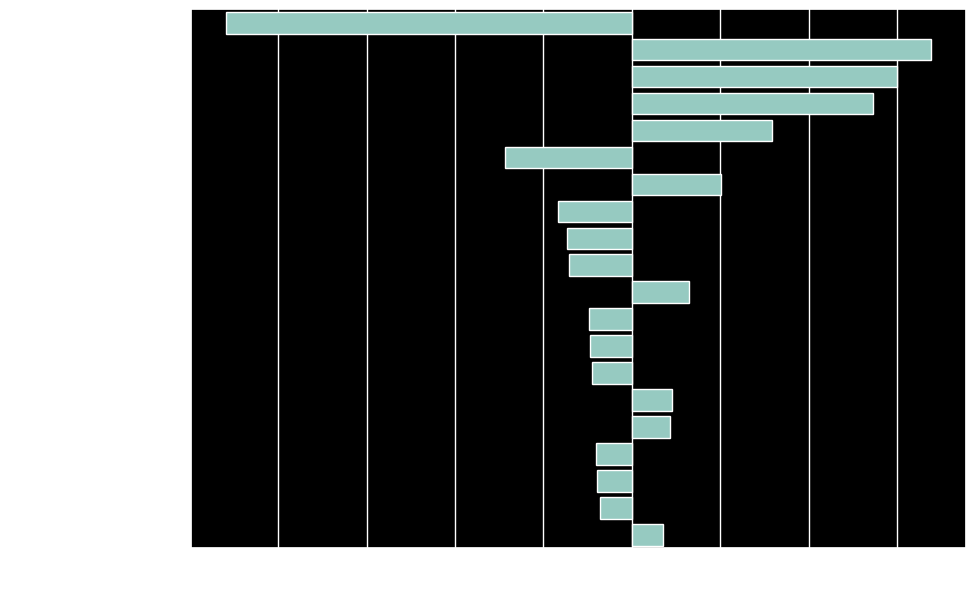

In [39]:
plt.figure(figsize=(10,7))
sns.barplot(data=coef_df.head(20), x='Coefficient', y='Feature', )

## Making Predictions and Evaluating the Model

We can now use the trained model to make predictions on the training, test 

In [49]:
X_train = train_inputs[numeric_cols]
X_val = val_inputs[numeric_cols]
X_test = test_inputs[numeric_cols]



In [56]:
train_targets = np.array([train_targets]).flatten()

In [68]:
train_preds = model.predict(X_train)
train_preds_df = pd.DataFrame({'train_preds' : train_preds, 'train_targets': train_targets.flatten()})
train_preds_df

,train_preds,train_targets
0,No,No
1,No,No
2,No,No
3,No,No
4,No,No
...,...,...
97983,No,No
97984,No,No
97985,No,No
97986,No,No


We can test the accuracy of the model's predictions by computing the percentage of matching values in `train_preds` and `train_targets`.

This can be done using the `accuracy_score` function from `sklearn.metrics`.

In [69]:
from sklearn.metrics import accuracy_score
accuracy_score(train_targets, train_preds)

0.8519206433440829

In [70]:
model.predict_proba(X_train)

array([[0.94401116, 0.05598884],
       [0.94074153, 0.05925847],
       [0.96093612, 0.03906388],
       ...,
       [0.98749113, 0.01250887],
       [0.98334678, 0.01665322],
       [0.87453425, 0.12546575]])

In [72]:
train_preds_df['prob_0'] = model.predict_proba(X_train)[:,0]
train_preds_df['prob_1'] = model.predict_proba(X_train)[:,1]
train_preds_df

,train_preds,train_targets,prob_0,prob_1
0,No,No,0.944011,0.055989
1,No,No,0.940742,0.059258
2,No,No,0.960936,0.039064
3,No,No,0.988998,0.011002
4,No,No,0.723124,0.276876
...,...,...,...,...
97983,No,No,0.984075,0.015925
97984,No,No,0.990997,0.009003
97985,No,No,0.987491,0.012509
97986,No,No,0.983347,0.016653


The model achieves an accuracy of 85.1% on the training set. We can visualize the breakdown of correctly and incorrectly classified inputs using a confusion matrix.
![alt text](UM28BCN-1.png)

In [77]:
from sklearn.metrics import confusion_matrix
confusion_matrix(train_targets, train_preds, normalize='true')

array([[0.94621341, 0.05378659],
       [0.4776585 , 0.5223415 ]])

Let's define a helper function to generate predictions, compute the accuracy score and plot a confusion matrix for a given st of inputs.

In [80]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets,preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    c_mat = confusion_matrix(targets,preds, normalize='true')
    sns.heatmap(c_mat, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));
    
    return preds

Accuracy: 85.19%


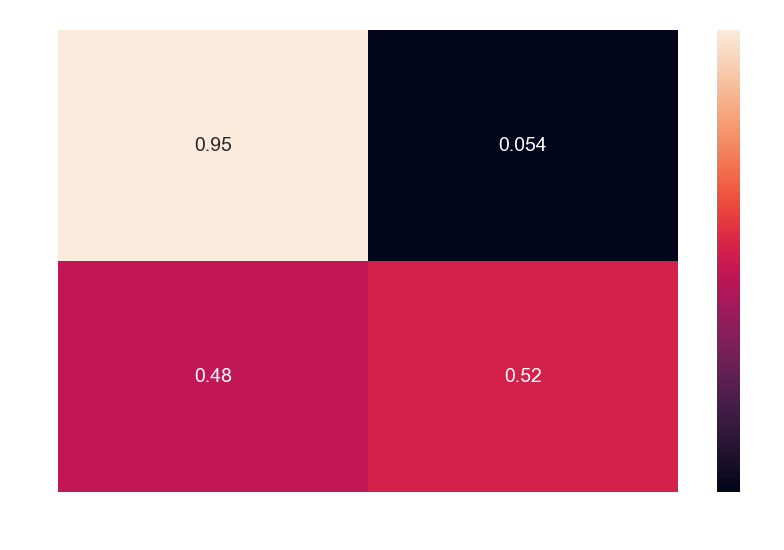

In [81]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 85.40%


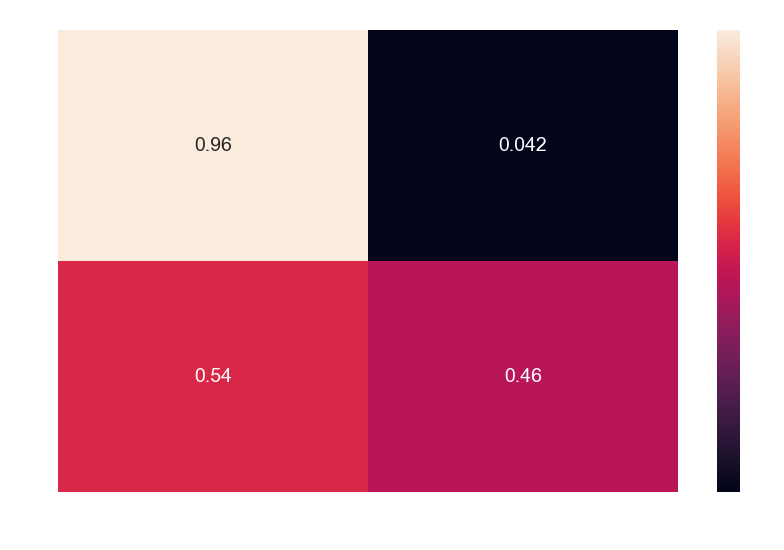

In [82]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

Accuracy: 84.20%


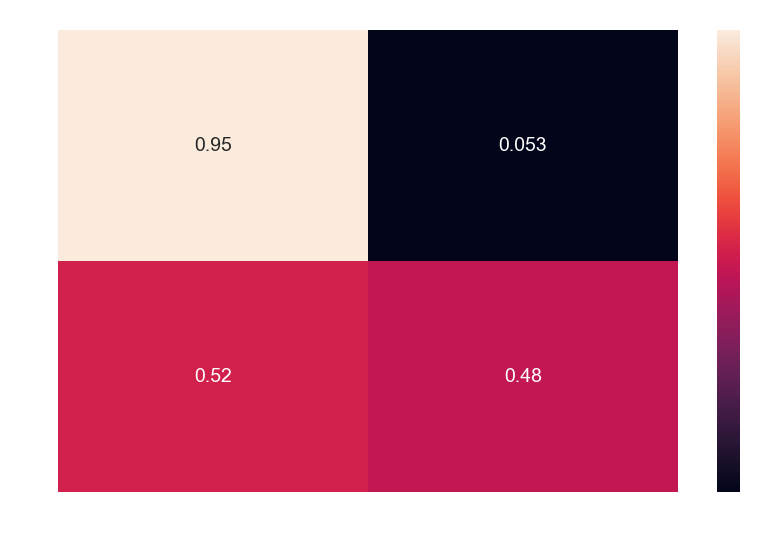

In [83]:
test_preds = predict_and_plot(X_test, test_targets, "Testing")

The accuracy of the model on the test and validation set are above 84%, which suggests that our model generalizes well to data it hasn't seen before. 

But how good is 84% accuracy? While this depends on the nature of the problem and on business requirements, a good way to verify whether a model has actually learned something useful is to compare its results to a "random" or "dumb" model.

Let's create two models: one that guesses randomly and another that always return "No". Both of these models completely ignore the inputs given to them.

In [84]:
def random_guess(inputs):
    return np.random.choice(["No", "Yes"], len(inputs))

def all_no(inputs):
    return np.full(len(inputs),'No')

In [85]:
accuracy_score(test_targets, random_guess(X_test))

0.4971995332555426

In [86]:
accuracy_score(test_targets, all_no(X_test))

0.7734344612991054

Our random model achieves an accuracy of 50% and our "always No" model achieves an accuracy of 77%. 

Thankfully, our model is better than a "dumb" or "random" model! This is not always the case, so it's a good practice to benchmark any model you train against such baseline models.

## Making Predictions on a Single Input

Once the model has been trained to a satisfactory accuracy, it can be used to make predictions on new data. Consider the following dictionary containing data collected from the Katherine weather department today.

In [88]:
new_input = {'Date': '2021-06-19',
             'Location': 'Katherine',
             'MinTemp': 23.2,
             'MaxTemp': 33.2,
             'Rainfall': 10.2,
             'Evaporation': 4.2,
             'Sunshine': np.nan,
             'WindGustDir': 'NNW',
             'WindGustSpeed': 52.0,
             'WindDir9am': 'NW',
             'WindDir3pm': 'NNE',
             'WindSpeed9am': 13.0,
             'WindSpeed3pm': 20.0,
             'Humidity9am': 89.0,
             'Humidity3pm': 58.0,
             'Pressure9am': 1004.8,
             'Pressure3pm': 1001.5,
             'Cloud9am': 8.0,
             'Cloud3pm': 5.0,
             'Temp9am': 25.7,
             'Temp3pm': 33.0,
             'RainToday': 'Yes'}

The first step is to convert the dictionary into a Pandas dataframe, similar to `raw_df`. This can be done by passing a list containing the given dictionary to the `pd.DataFrame` constructor.

In [89]:
new_input_df = pd.DataFrame([new_input])
new_input_df



,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2021-06-19,Katherine,23.2,33.2,10.2,4.2,NaN,NNW,52.0,NW,...,20.0,89.0,58.0,1004.8,1001.5,8.0,5.0,25.7,33.0,Yes


We've now created a Pandas dataframe with the same columns as `raw_df` (except `RainTomorrow`, which needs to be predicted). The dataframe contains just one row of data, containing the given input.


We must now apply the same transformations applied while training the model:

1. Imputation of missing values using the `imputer` created earlier
2. Scaling numerical features using the `scaler` created earlier
3. Encoding categorical features using the `encoder` created earlier

In [94]:
import joblib

imputer = joblib.load('imputer.pkl')
scaler = joblib.load('scaler.pkl')
encoder = joblib.load('encoder.pkl')

In [95]:
new_input_df[numeric_cols] = imputer.transform(new_input_df[numeric_cols])
new_input_df[numeric_cols] = scaler.transform(new_input_df[numeric_cols])
new_input_df[encoded_cols] = encoder.transform(new_input_df[categorical_cols])

KeyError: "['Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_SalmonGums', 'Location_Sydney', 'Location_SydneyAirport', 'Location_Townsville', 'Location_Tuggeranong', 'Location_Uluru', 'Location_WaggaWagga', 'Location_Walpole', 'Location_Watsonia', 'Location_Williamt